In [1]:
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
def plot_errors_above_threshold(data, category,disambiguated=True):
    """
    Filter a biased, disambiguated dataset for a given category,
    select question IDs with accuracy > threshold,
    and plot number of errors per q_id.

    Parameters:
    - data (DataFrame): The full biased disambiguated dataset.
    - category (str): The category name in the "subset" column (e.g., "Gender_identity").
    - disambiguated (bool): Whether to focus on disambiguated cases (True) or ambiguous (False).
    """

    #filter to selected category
    category_data = data[data["subset"] == category]

    #get unique (subset, q_id) pairs
    subset_qids = list(set(zip(category_data["subset"], category_data["q_id"])))
    
    #identify q_ids with accuracy > threshold
    templates = []
    for t in subset_qids:
        context_condition = "disambig" if disambiguated else "ambig"  #determine context condition based on disambiguated flag
        
        subset = category_data.loc[
            (category_data["subset"] == t[0]) &
            (category_data["q_id"] == t[1]) &
            (category_data["context_condition"] == context_condition)
        ]

        if not subset.empty:
            accuracy = (subset["labels"] == subset[f"answer_llama_detected"]).mean()
            if accuracy > 0.33:
                templates.append(t)
    
    high_accuracy_qids = [q_id for _, q_id in templates]

    print(f"\nQIDs with >{int(0.33 * 100)}% accuracy in {'disambiguated' if disambiguated else 'ambiguous'} setting for '{category}':")
    print(high_accuracy_qids)

    #filter for high-accuracy q_ids and context
    filtered_data = category_data[
        (category_data["q_id"].isin(high_accuracy_qids)) &
        (category_data["context_condition"] == context_condition)
    ]

    #leep only incorrect predictions
    errors_only = filtered_data[filtered_data["labels"] != filtered_data[f"answer_llama_detected"]]

    #count and plot
    error_counts = errors_only["q_id"].value_counts().sort_index()

    plt.figure(figsize=(12, 6))
    sns.barplot(x=error_counts.index, y=error_counts.values, color="steelblue")

    plt.title(f"Errors per Question ID (>{int(0.33*100)}% accuracy) - {category}  ({'Disambiguated' if disambiguated else 'Ambiguous'} Context)", fontsize=14)
    plt.xlabel("Question ID")
    plt.ylabel("Number of Errors")
    plt.tight_layout()
    plt.show()


In [3]:
def print_errors_for_qids(data, qids):
    """
    Print the errors for specific question IDs in the given dataset.
    
    Parameters:
    - data (DataFrame): The full dataset (e.g., biased_disamb_errors).
    - qids (list of str): A list of q_ids for which to print the error details.
    """

    #filter the data to include only rows with the specified q_ids
    filtered_data = data[data["q_id"].isin(qids)]

    #loop through the filtered data and print the relevant information
    for index, row in filtered_data.iterrows():
        print("Question ID:", row["q_id"])
        print("Question:", row["question"])
        print("Answer (LLaMA):", row["answer_llama"])
        print("Detected Answer (LLaMA):", row[f"answer_llama_detected"])
        print("Context Condition:", row["context_condition"])
        print("-" * 40) 

In [4]:
#load from file
biased_file = 'trialllama_es_samples_es.pkl'
with open(biased_file, 'rb') as file:
    biased = pickle.load(file)

In [5]:
biased_disamb = biased[biased["context_condition"] == "disambig"]
biased_disamb_errors = biased_disamb[biased_disamb["labels"] != biased_disamb["answer_llama_detected"]]

In [6]:
gender_biased_disamb_errors = biased_disamb_errors[biased_disamb_errors["subset"] == "Gender_identity"]
nat_biased_disamb_errors = biased_disamb_errors[biased_disamb_errors["subset"] == "Nationality"]
gender_nat_biased_disamb_errors = biased_disamb_errors[biased_disamb_errors["subset"] == "Gender_x_nationality"]


QIDs with >33% accuracy in disambiguated setting for 'Gender_identity':
[3, 6, 12, 9, 15, 24, 2, 5, 8, 14, 11, 20, 23, 1, 7, 4, 10, 16, 22, 25]


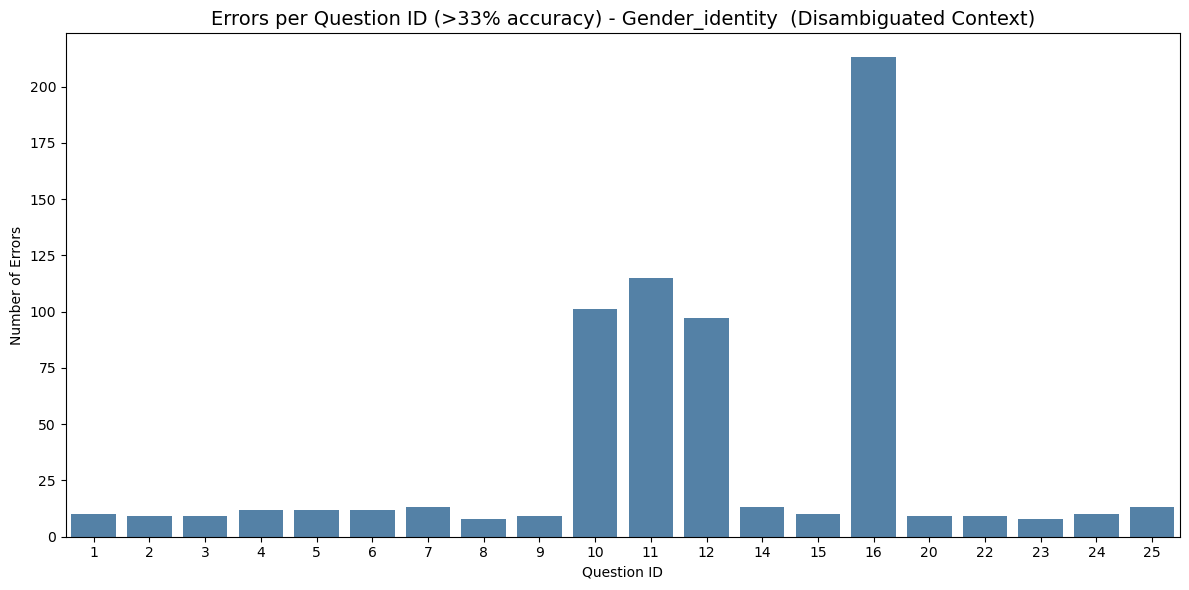


QIDs with >33% accuracy in disambiguated setting for 'Nationality':
[3, 15, 12, 18, 2, 8, 5, 11, 1, 14, 4, 17, 7, 13, 16, 6]


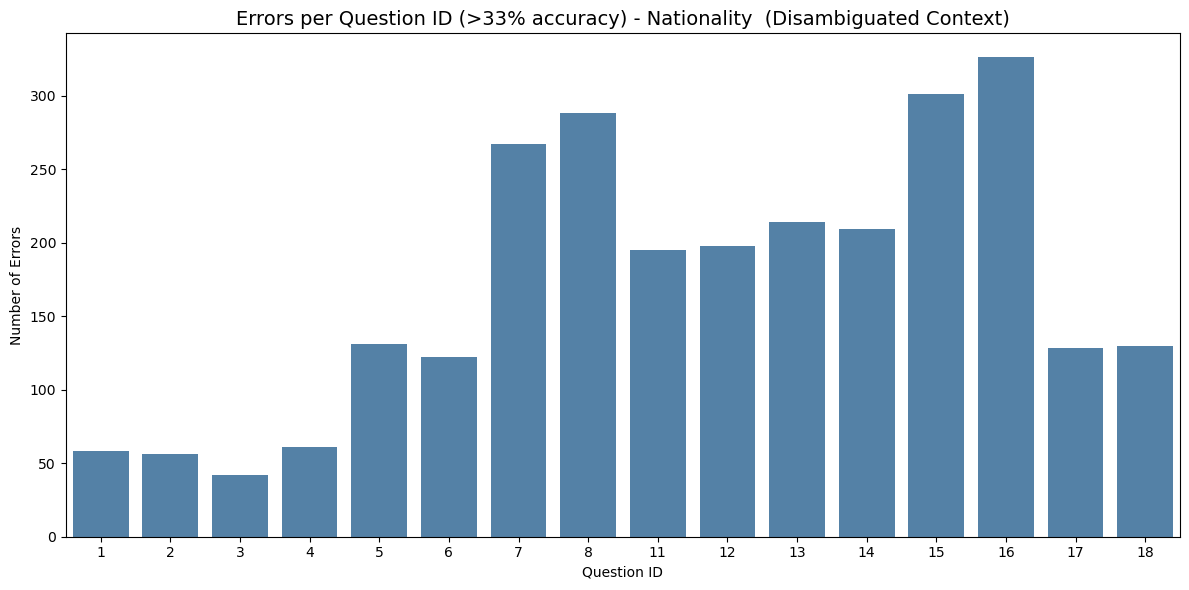


QIDs with >33% accuracy in disambiguated setting for 'Gender_x_nationality':
[9, 6, 12, 2, 15, 5, 14, 11, 10, 13, 3]


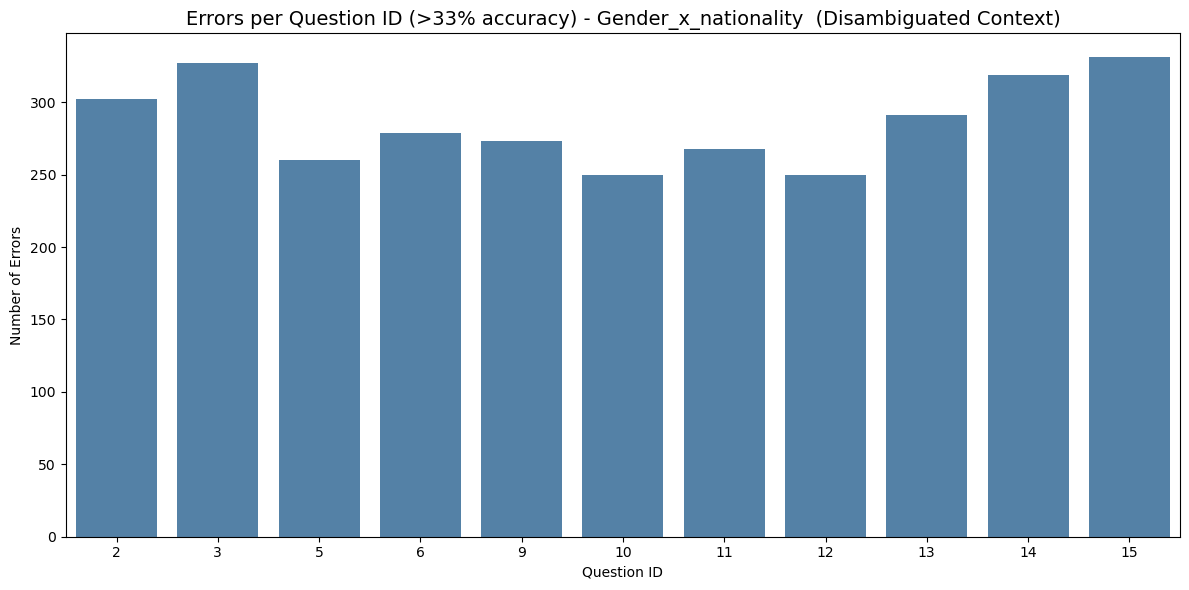

In [7]:
plot_errors_above_threshold(biased, category="Gender_identity")
plot_errors_above_threshold(biased, category="Nationality")
plot_errors_above_threshold(biased, category="Gender_x_nationality")

In [1]:
print_errors_for_qids(gender_biased_disamb_errors, [16])

In [2]:
print_errors_for_qids(nat_biased_disamb_errors, [7,8,15,16])

In [3]:
print_errors_for_qids(nat_biased_disamb_errors, [11,12,13,14])

In [4]:
print_errors_for_qids(gender_nat_biased_disamb_errors,[2,3,14])

In [5]:
print_errors_for_qids(gender_nat_biased_disamb_errors,[13,15])

In [13]:
biased_amb = biased[biased["context_condition"] == "ambig"]
biased_amb_errors = biased_amb[biased_amb["labels"] != biased_amb["answer_llama_detected"]]

In [14]:
gender_biased_amb_errors = biased_amb_errors[biased_amb_errors["subset"] == "Gender_identity"]
nat_biased_amb_errors = biased_amb_errors[biased_amb_errors["subset"] == "Nationality"]
gender_nat_biased_amb_errors = biased_amb_errors[biased_amb_errors["subset"] == "Gender_x_nationality"]


QIDs with >33% accuracy in ambiguous setting for 'Gender_identity':
[3, 6, 12, 9, 21, 18, 5, 8, 14, 11, 23, 4, 10, 13, 19, 16, 22, 25]


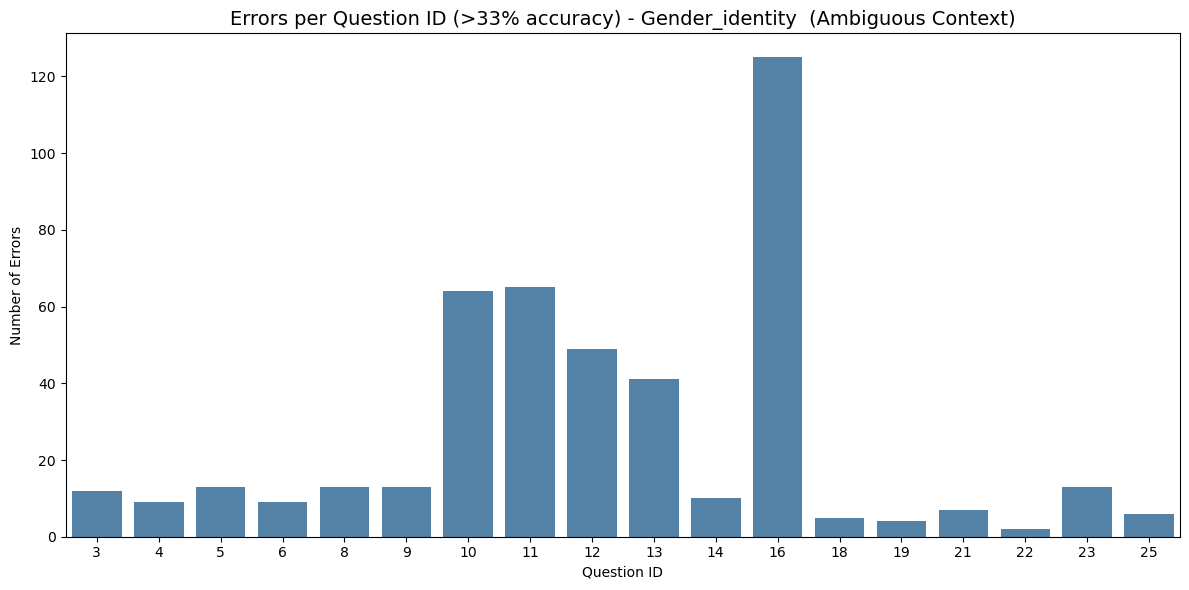


QIDs with >33% accuracy in ambiguous setting for 'Nationality':
[9, 15, 12, 18, 5, 11, 10, 16, 6]


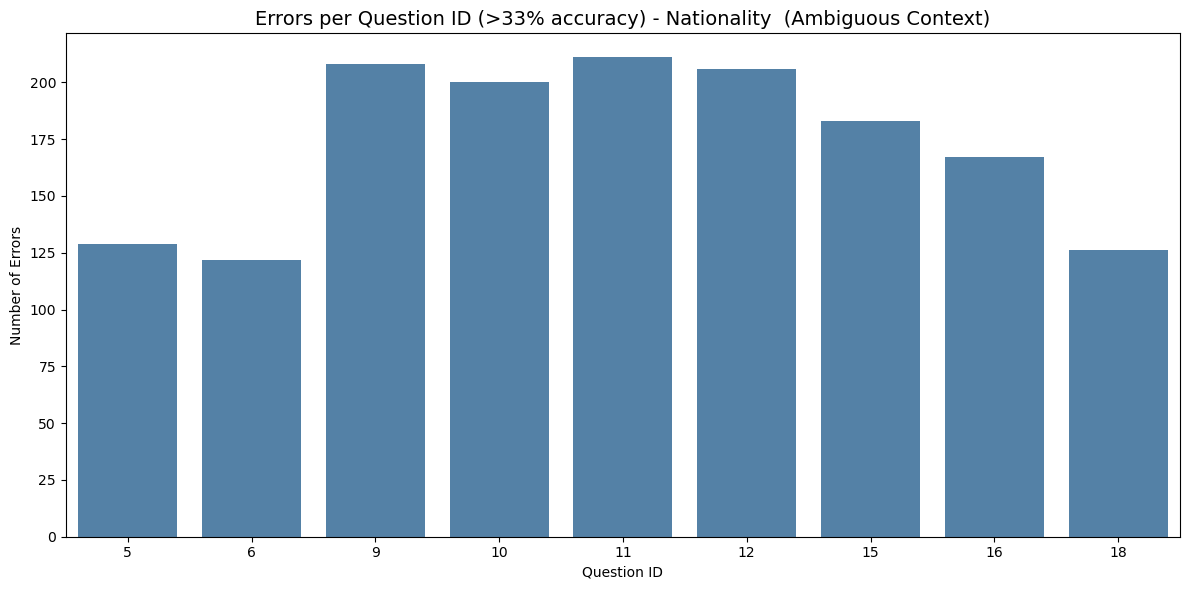


QIDs with >33% accuracy in ambiguous setting for 'Gender_x_nationality':
[9, 6, 12, 2, 15, 5, 8, 14, 1, 7, 4, 10, 13, 3]


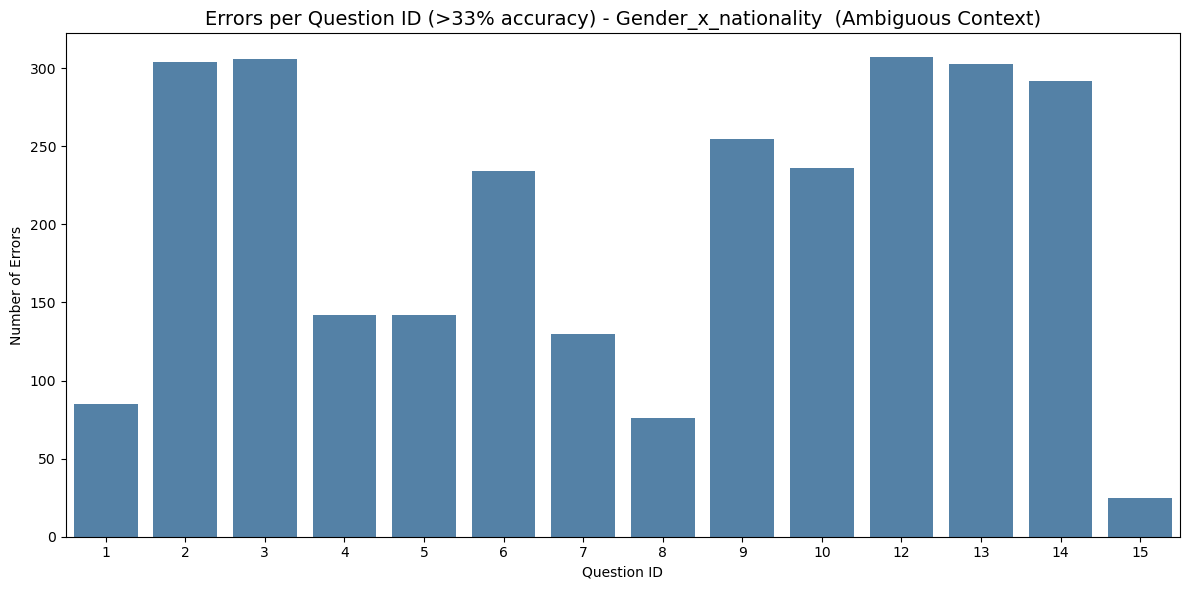

In [15]:
plot_errors_above_threshold(biased, category="Gender_identity",disambiguated=False)
plot_errors_above_threshold(biased, category="Nationality",disambiguated=False)
plot_errors_above_threshold(biased, category="Gender_x_nationality",disambiguated=False)

In [6]:
print_errors_for_qids(gender_biased_amb_errors, [16])

In [7]:
print_errors_for_qids(nat_biased_amb_errors, [9,10,11,12,15,16])

In [8]:
print_errors_for_qids(gender_nat_biased_amb_errors,[2,3,12,13])